# Chapter 7: Analyzing the Heart Disease Dataset

## 1. Introduction
Trong chương này, bộ dữ liệu Heart Disease được sử dụng để phân tích các yếu tố liên quan đến khả năng mắc bệnh tim của bệnh nhân. Bộ dữ liệu gồm 303 mẫu và 14 thuộc tính, bao gồm các thông tin như tuổi, giới tính, loại đau ngực, huyết áp khi nghỉ, cholesterol, đường huyết, kết quả điện tâm đồ, nhịp tim tối đa và biến mục tiêu `target`.

Mục tiêu của notebook không phải là xây dựng mô hình dự đoán, mà là thực hiện phân tích khám phá dữ liệu (EDA). Cụ thể, notebook tập trung vào việc kiểm tra missing values, phát hiện outliers, quan sát phân bố dữ liệu và phân tích mối quan hệ giữa các đặc trưng với biến mục tiêu.

## 2. Loading and Understanding the Data

### 2.1 import thư viện

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ModuleNotFoundError: No module named 'pandas'

### 2.2 Đọc file csv và mô tả dataset

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/'\
                 'PacktWorkshops/'\
                 'The-Data-Analysis-Workshop/master/'\
                 'Chapter07/Dataset/heart.csv')

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Bảng thống kê cho thấy:
- Dataset gồm 303 bản ghi cho mỗi thuộc tính.
- Giá trị trung bình (mean) và các phân vị (quartiles) giúp ta hiểu phân bố dữ liệu.
- Một số thuộc tính có sự chênh lệch lớn giữa giá trị lớn nhất và giá trị Q3, ví dụ:
    - Cholesterol có max = 564, cao hơn nhiều so với Q3 (~274) → dấu hiệu rõ ràng của phân bố lệch phải (right-skewed distribution)

=> Điều này cho thấy dữ liệu không hoàn toàn tuân theo phân bố chuẩn và cần kiểm tra trực quan.

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Sau khi đọc dữ liệu, ta quan sát một vài dòng đầu tiên để kiểm tra cấu trúc bảng dữ liệu. Các cột ban đầu sử dụng nhiều thuật ngữ viết tắt trong y khoa như `cp`, `trestbps`, `thalach`, `oldpeak`, `ca`, `thal`. Vì vậy, cần đổi tên một số cột sang dạng dễ hiểu hơn để thuận tiện cho quá trình phân tích.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


- Kết quả `info()` cho thấy dữ liệu có 303 quan sát và 14 cột. 
- Tất cả các cột đều có kiểu dữ liệu số, bao gồm `int64` và `float64`. 
- Ngoài ra, số lượng giá trị non-null ở các cột đều bằng 303, cho thấy dataset không có missing values.

=> Điều này giúp quá trình phân tích thuận lợi hơn vì không cần xử lý dữ liệu thiếu trước khi trực quan hóa.

Tuy nhiên:

- Một số biến thực chất là categorical như `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`, `target` nhưng đang được biểu diễn dưới dạng số.

=> Cần cẩn thận khi diễn giải vì đây không phải tất cả đều là dữ liệu liên tục thực sự.

In [ ]:
df.rename(index = str, \
          columns = {'cp' : 'chest_pain', \
                     'trestbps' : 'rest_bp', \
                     'fbs' : 'fast_bld_sugar', \
                     'restecg' : 'rest_ecg', \
                     'thalach' : 'max_hr', \
                     'exang' : 'ex_angina', \
                     'oldpeak' : 'st_depr', \
                     'ca' : 'colored_vessels', \
                     'thal' : 'thalassemia', }, inplace = True)


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              303 non-null    int64  
 1   sex              303 non-null    int64  
 2   chest_pain       303 non-null    int64  
 3   rest_bp          303 non-null    int64  
 4   chol             303 non-null    int64  
 5   fast_bld_sugar   303 non-null    int64  
 6   rest_ecg         303 non-null    int64  
 7   max_hr           303 non-null    int64  
 8   ex_angina        303 non-null    int64  
 9   st_depr          303 non-null    float64
 10  slope            303 non-null    int64  
 11  colored_vessels  303 non-null    int64  
 12  thalassemia      303 non-null    int64  
 13  target           303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.5+ KB


Sau khi đổi tên cột, các thuộc tính trở nên dễ hiểu hơn. 
- Ví dụ: `cp` được đổi thành `chest_pain`, `trestbps` thành `rest_bp`, `thalach` thành `max_hr`, `oldpeak` thành `st_depr`, và `ca` thành `colored_vessels`.

Việc đổi tên này không làm thay đổi dữ liệu, nhưng giúp việc đọc biểu đồ và diễn giải kết quả rõ ràng hơn, đặc biệt đối với người không quen với thuật ngữ y khoa.

In [ ]:
df.isnull().sum()

age                0
sex                0
chest_pain         0
rest_bp            0
chol               0
fast_bld_sugar     0
rest_ecg           0
max_hr             0
ex_angina          0
st_depr            0
slope              0
colored_vessels    0
thalassemia        0
target             0
dtype: int64

Kết quả kiểm tra missing values cho thấy tất cả các cột đều không có giá trị thiếu. Vì vậy, notebook không cần thực hiện các bước xử lý như xóa dòng, điền trung bình, điền trung vị hoặc nội suy dữ liệu.

Đây là một điểm thuận lợi của dataset vì ta có thể chuyển trực tiếp sang bước phân tích phân bố và mối quan hệ giữa các biến.

In [ ]:
print(df.duplicated().sum())
df[df.duplicated(keep=False)]


1


,age,sex,chest_pain,rest_bp,chol,fast_bld_sugar,rest_ecg,max_hr,ex_angina,st_depr,slope,colored_vessels,thalassemia,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [ ]:
df.drop_duplicates(inplace = True)

df[df.duplicated(keep=False)]

,age,sex,chest_pain,rest_bp,chol,fast_bld_sugar,rest_ecg,max_hr,ex_angina,st_depr,slope,colored_vessels,thalassemia,target


- Tiến hành kiểm tra và xử lý các dòng dữ liệu trùng lặp nhằm đảm bảo chất lượng dữ liệu trước khi phân tích. 
- Các bản ghi trùng lặp có thể làm sai lệch tần suất phân bố của các biến và ảnh hưởng đến nhận xét khi trực quan hóa.

Sau khi loại bỏ dữ liệu trùng, dataset được sử dụng cho các bước phân tích tiếp theo sẽ đại diện cho các quan sát duy nhất. 

=> Điều này giúp kết quả EDA phản ánh dữ liệu sạch hơn, dù số lượng mẫu có thể thay đổi so với dữ liệu ban đầu.

In [ ]:
continuous = []
discrete = []

for i in df.columns: 
    if df[i].nunique() < 10:
        discrete.append(i)
    else: 
        continuous.append(i)
        
print("Continuous: ", continuous)
print("Discrete: ", discrete)

Continuous:  ['age', 'rest_bp', 'chol', 'max_hr', 'st_depr']
Discrete:  ['sex', 'chest_pain', 'fast_bld_sugar', 'rest_ecg', 'ex_angina', 'slope', 'colored_vessels', 'thalassemia', 'target']


Các biến trong dataset có thể chia thành ba nhóm chính, việc phân biệt nhóm biến này giúp lựa chọn biểu đồ phù hợp:
- Biến liên tục (Continuous Variable): nhận các giá trị trong 1 khoảng liên tục như đo lường (measurement), số thực, số thập phân,..
=> thường sủ dụng biểu đồ histogram, boxplot

- Biến rời rạc (Discrete Variable) : nhận các giá trị có thể đếm được, hoặc có thể phân loại như 0 và 1 => thường sử dụng biểu đồ countplot
    - giới tính (0,1)
    - loại đau ngực (0,1,2,3)
    - số mạch máu (0,1,2,3,4)
    - target (0,1)

- Biến nhị phân (binary) => Phù hợp với countplot/bar chart để so sánh số lượng giữa hai nhóm.

## 3. Exploratory Data Analysis

### 3.1 Checking for Outliers
Outlier là những giá trị khác biệt đáng kể so với phần lớn dữ liệu. Trong phân tích dữ liệu, outliers cần được kiểm tra vì chúng có thể ảnh hưởng đến nhận xét thống kê và kết quả mô hình sau này.

Theo thống kê mô tả, một số cột như `chol`, `st_depr`, `colored_vessels` và `thalassemia` có dấu hiệu xuất hiện giá trị bất thường. Vì vậy, ta sử dụng boxplot để quan sát rõ hơn các giá trị ngoại lai này.

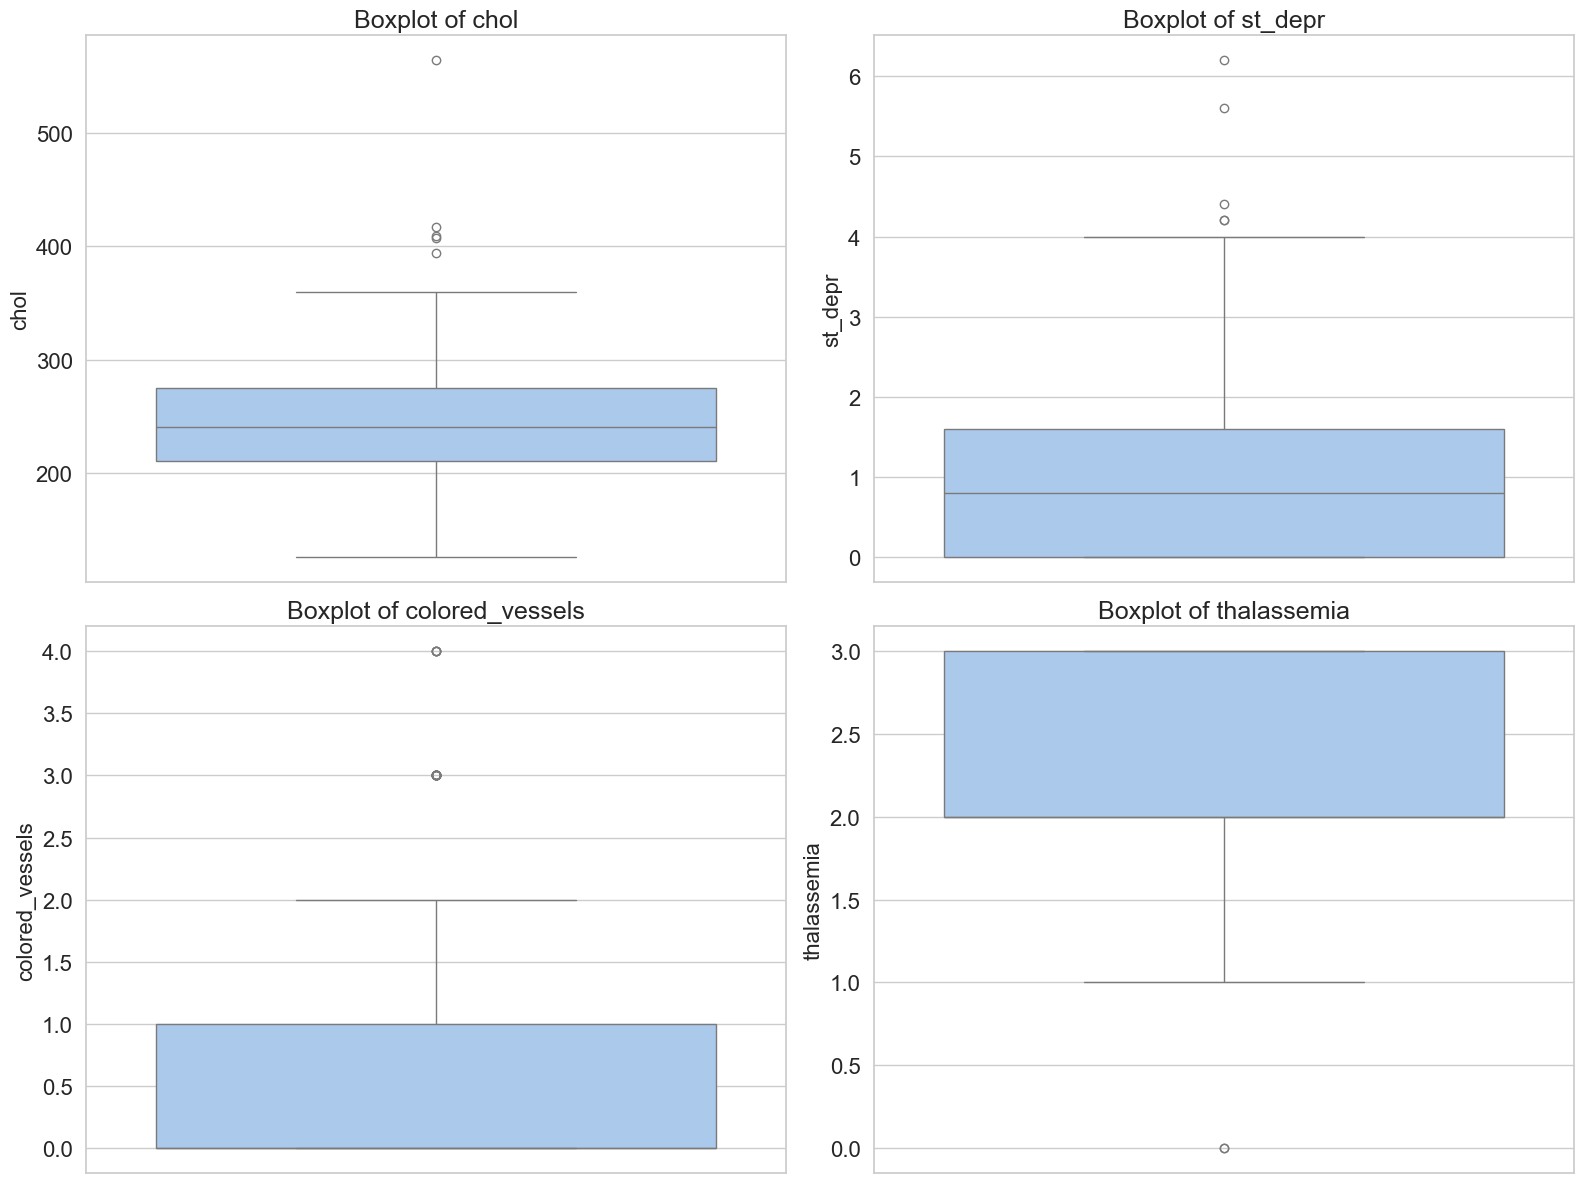

In [ ]:
fts_outliers =  ['chol', 'st_depr', 'colored_vessels', 'thalassemia']

figs, axes = plt.subplots(2, 2, figsize = (16,12))

for i, col in enumerate(fts_outliers):
    sns.boxplot(df[col], ax = axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Boxplot of {col}', fontsize = 18)

# sns.set(palette = 'pastel', rc = {"figure.figsize": (12,8), \
#                                   "axes.titlesize" : 18, \
# "axes.labelsize" : 16, \
# "xtick.labelsize" : 16, \
# "ytick.labelsize" : 16 })

# chol = sns.boxplot(df['chol'])
plt.tight_layout()
plt.show()


Biểu đồ boxplot cho thấy các cột `chol`, `st_depr`, `colored_vessels` và `thalassemia` đều xuất hiện một số outliers.

Đặc biệt, biến `chol` có một số giá trị cholesterol rất cao so với phần lớn dữ liệu. Điều này phù hợp với thống kê mô tả khi giá trị lớn nhất của cholesterol cao hơn nhiều so với phân vị thứ ba. Với `st_depr`, một số điểm cũng nằm xa phần dữ liệu chính, cho thấy mức ST depression bất thường ở một vài bệnh nhân.

Tuy nhiên, trong bối cảnh dữ liệu y tế, outliers không nhất thiết là dữ liệu sai. Chúng có thể phản ánh các trường hợp bệnh lý nghiêm trọng hoặc hiếm gặp. Do dataset chỉ có 303 mẫu, notebook không loại bỏ hoặc thay thế các outliers mà chỉ ghi nhận để phục vụ phân tích.

### 3.2 Distribution of Age, Target and Sex

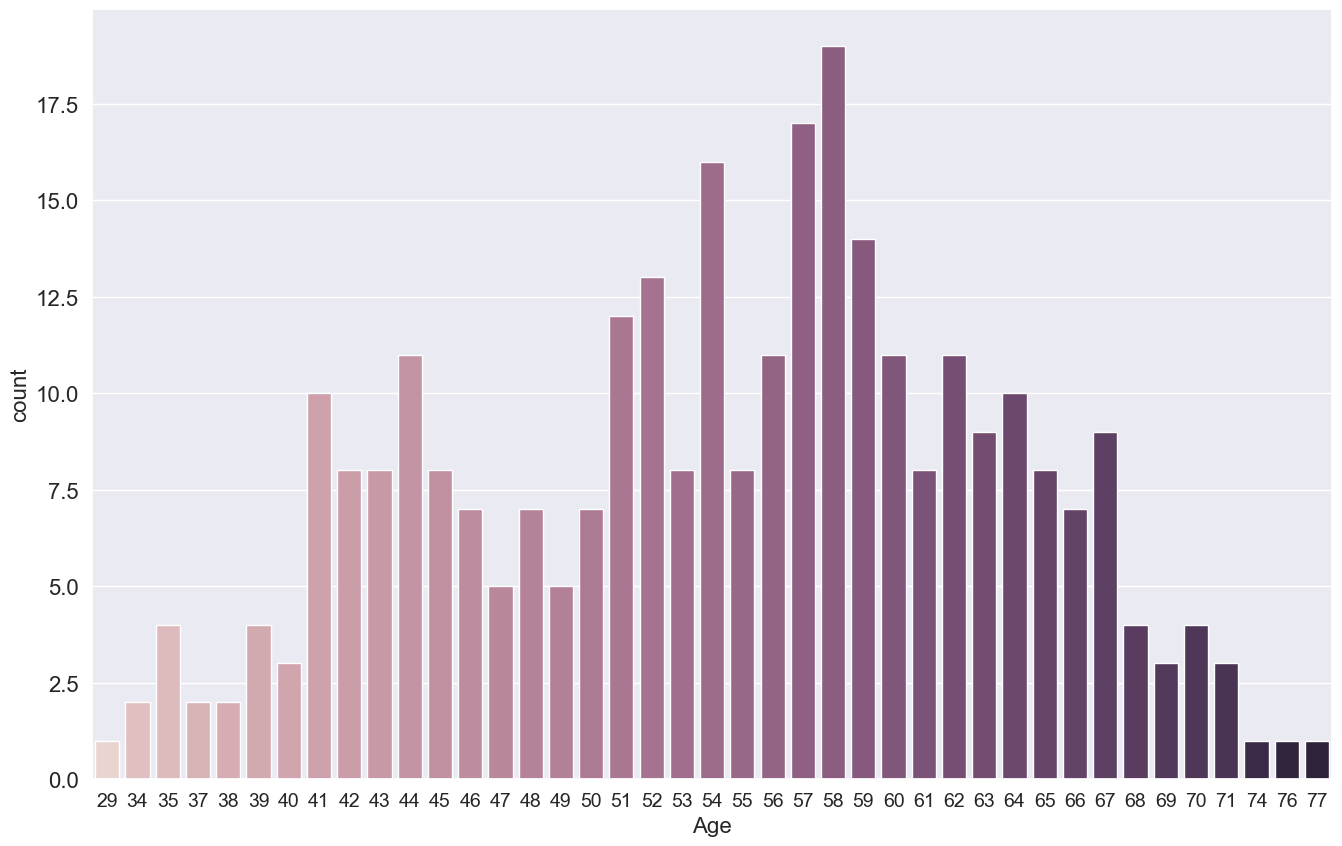

In [ ]:
sns.set(palette = 'pastel', rc = {"figure.figsize": (16,10), \
                                  "axes.titlesize" : 18, \
"axes.labelsize" : 16, \
"xtick.labelsize" : 14, \
"ytick.labelsize" : 16 })


g = sns.countplot(x = 'age', data = df, hue = 'age', legend = False)
plt.xlabel('Age')

plt.show()

- Biểu đồ phân bố tuổi cho thấy độ tuổi của bệnh nhân dao động từ 29 đến 77. 
- Phần lớn bệnh nhân tập trung trong khoảng 50 đến đầu 60 tuổi, trong đó nhóm tuổi quanh 58 xuất hiện nhiều nhất.

Điều này cho thấy dataset chủ yếu phản ánh nhóm bệnh nhân trung niên và lớn tuổi. Vì vậy, khi diễn giải các đặc trưng y khoa khác, cần lưu ý rằng dữ liệu không đại diện đồng đều cho mọi nhóm tuổi.

In [ ]:
df.target.value_counts()

target
1    164
0    138
Name: count, dtype: int64

Kết quả cho thấy có 164 bệnh nhân thuộc nhóm có bệnh tim (`target = 1`) và 138 bệnh nhân thuộc nhóm không có bệnh tim (`target = 0`). 

Sự chênh lệch giữa hai nhóm không quá lớn, vì vậy có thể xem dataset tương đối cân bằng theo biến mục tiêu.

Điều này giúp việc phân tích trở nên đáng tin cậy hơn vì không có một lớp nào chiếm ưu thế quá mạnh.

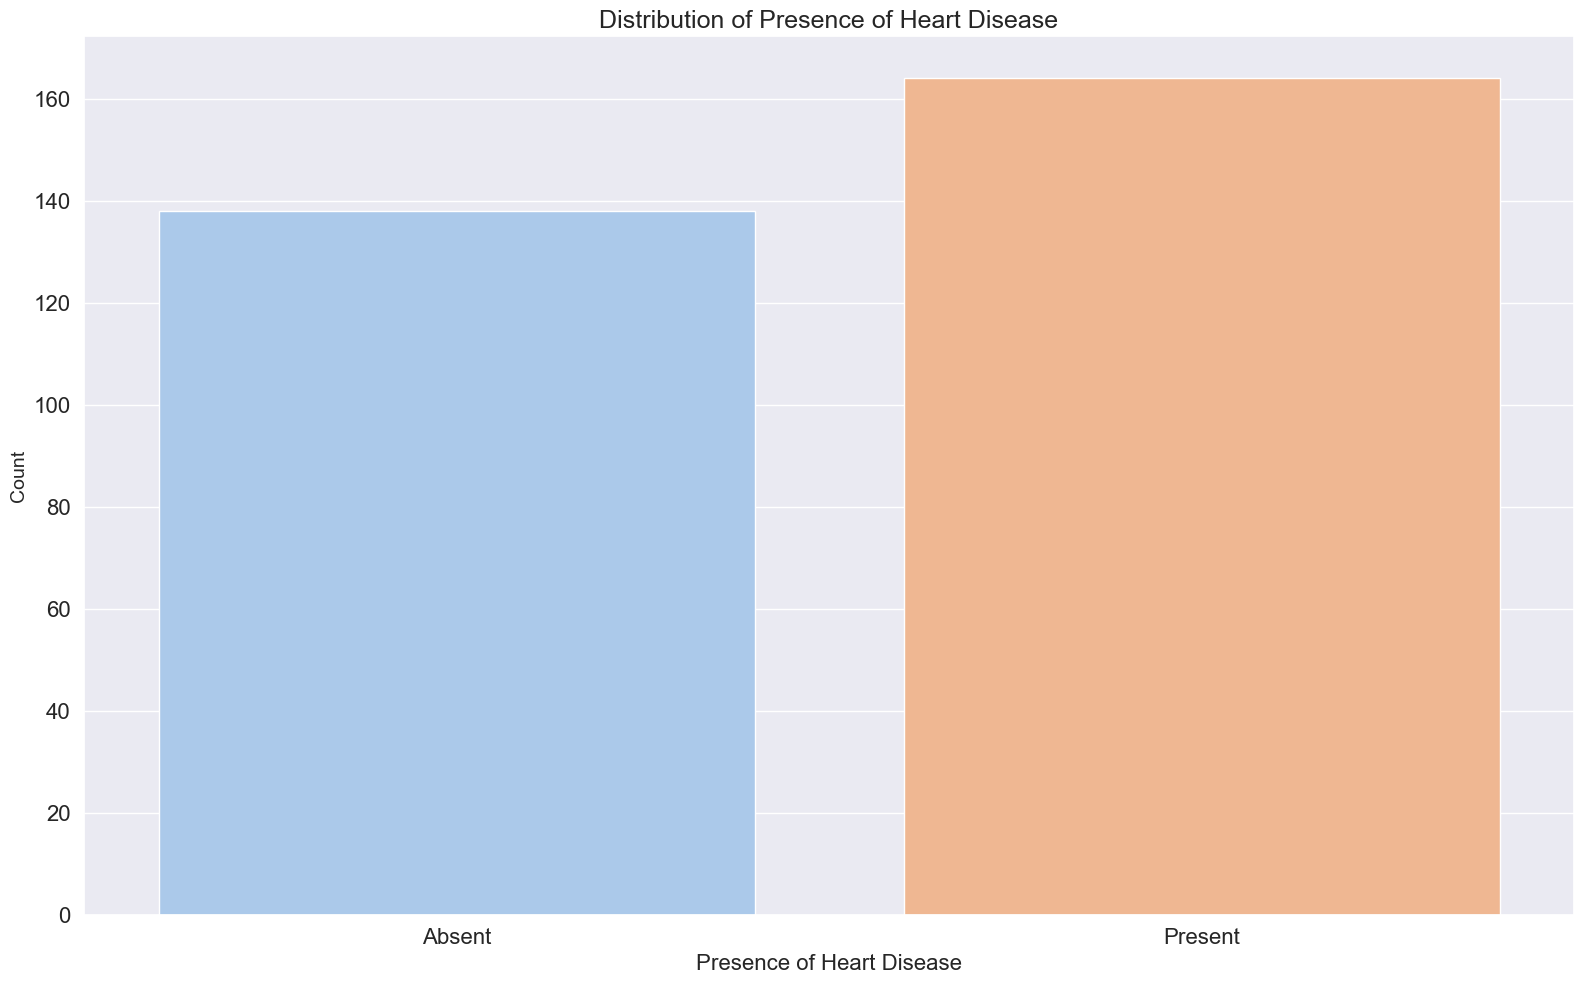

In [ ]:
a = sns.countplot(x = 'target', data = df, hue= 'target', palette='pastel', legend = False)

a.set_title('Distribution of Presence of Heart Disease')
a.set_xticks([0, 1])
a.set_xticklabels(['Absent', 'Present'], fontsize = 16)

plt.xlabel("Presence of Heart Disease", fontsize = 16)
plt.ylabel("Count", fontsize = 14)

plt.tight_layout()
plt.show()


Biểu đồ phân bố biến mục tiêu xác nhận rằng số lượng bệnh nhân có và không có bệnh tim khá tương đồng. Nhóm có bệnh tim cao hơn một chút, nhưng mức chênh lệch không lớn.

Do đó, các phân tích tiếp theo giữa `target` và các đặc trưng khác có thể được thực hiện mà không cần xử lý mất cân bằng lớp.

In [ ]:
df.sex.value_counts()

sex
1    206
0     96
Name: count, dtype: int64

Kết quả cho thấy số lượng bệnh nhân nam (1) nhiều hơn nữ (0) đáng kể. Cụ thể, dataset có 206 bệnh nhân nam và 96 bệnh nhân nữ.

Điều này cho thấy dữ liệu bị mất cân bằng theo giới tính. 

Vì vậy, khi phân tích quan hệ giữa giới tính và bệnh tim, cần xét đến sự chênh lệch số lượng mẫu giữa hai nhóm.

In [ ]:
b = sns.countplot(x = 'target', data = df, hue = 'sex', palette='pastel', legend = False)

b.set_title('Distribution of Presence of Heart Disease by Sex')

b.set_xticks([0, 1])
b.set_xticklabels(['KhongBenh', 'CoBenh'], fontsize = 16)

plt.legend(labels=['Female', 'Male'])
plt.tight_layout()
plt.show()


NameError: name 'sns' is not defined

Biểu đồ cho thấy ở nhóm nữ, số bệnh nhân mắc bệnh tim cao hơn số bệnh nhân không mắc bệnh tim.  Ngược lại, ở nhóm nam, số bệnh nhân không mắc bệnh tim nhiều hơn số bệnh nhân mắc bệnh tim.

Tuy nhiên, do số lượng nam và nữ trong dataset không cân bằng => không nên kết luận tuyệt đối rằng giới tính là nguyên nhân trực tiếp dẫn đến bệnh tim. 

Kết quả này chỉ cho thấy trong dataset hiện tại, phân bố bệnh tim khác nhau giữa hai nhóm giới tính.

### 3.3 Relationship between Categorical Features and Target

Trong phần này, ta phân tích một số biến phân loại quan trọng gồm `chest_pain`, `colored_vessels` và `slope`. Mục tiêu là quan sát xem các nhóm giá trị khác nhau của từng đặc trưng có liên quan như thế nào đến biến mục tiêu `target`.

In [ ]:
df.chest_pain.value_counts()

chest_pain
0    143
2     86
1     50
3     23
Name: count, dtype: int64

Kết quả cho thấy:

- Loại đau ngực phổ biến nhất là nhóm `0`, tiếp theo là nhóm `2`, nhóm `1` và cuối cùng là nhóm `3`.

=> Điều này cho thấy phân bố các loại đau ngực không đồng đều trong dataset.

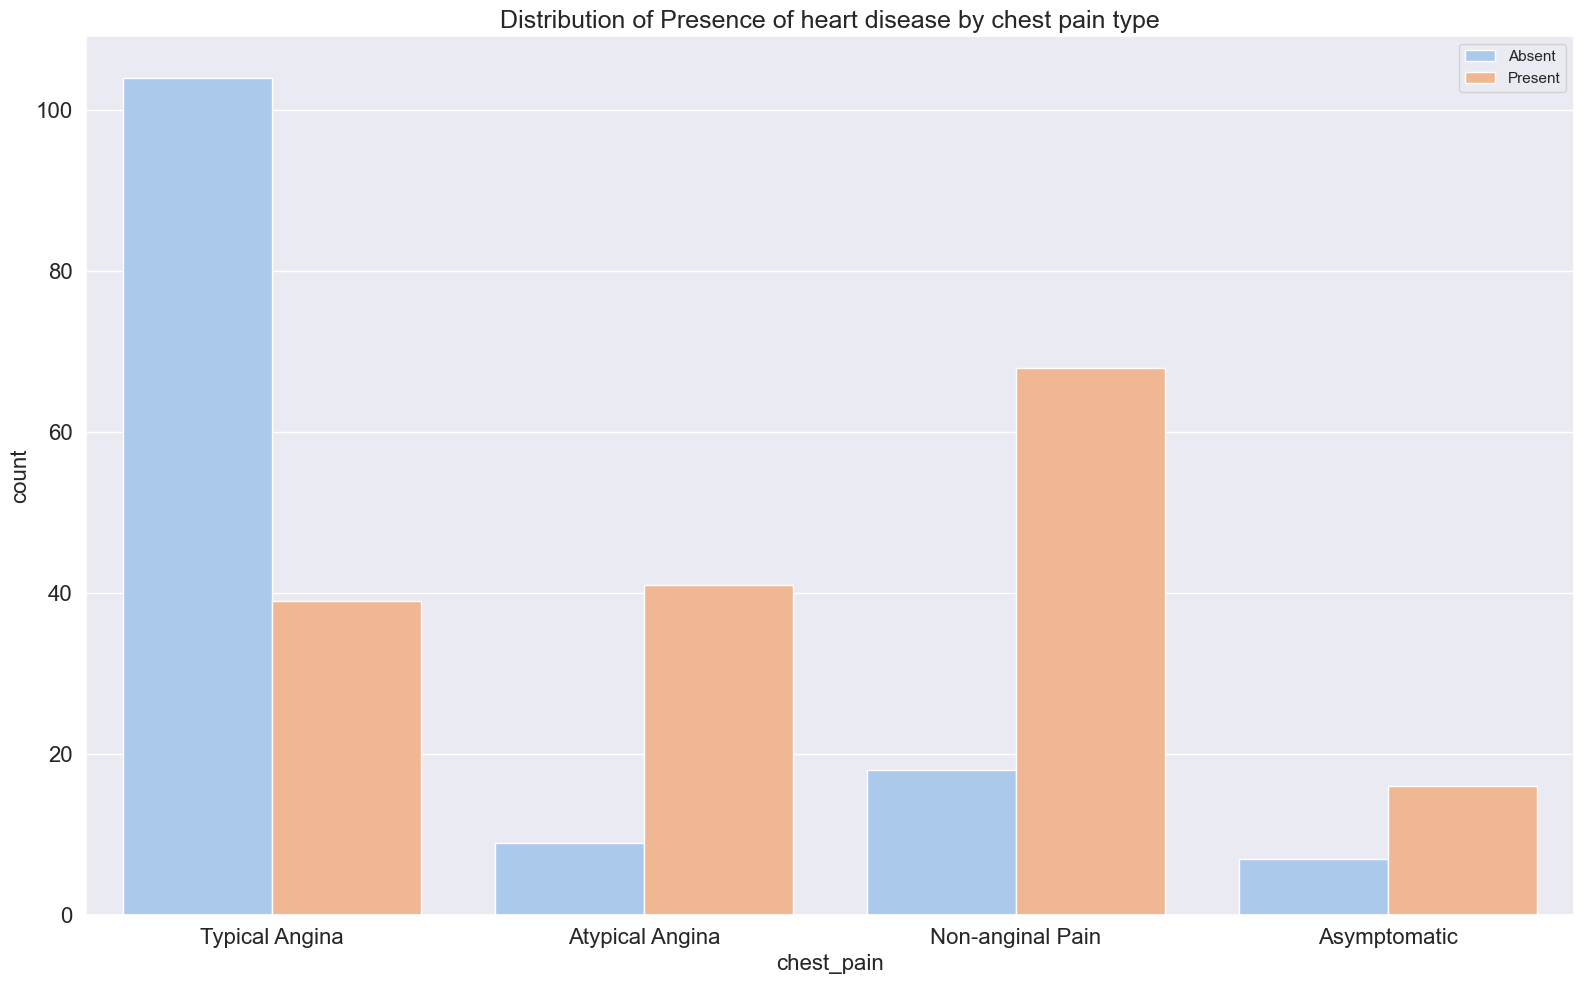

In [ ]:
c = sns.countplot(x = 'chest_pain', data = df, hue = 'target', palette='pastel', legend = False)

c.set_title('Distribution of Presence of heart disease by chest pain type')
c.set_xticks([0, 1, 2, 3])
c.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.show()

Biểu đồ cho thấy nhóm `Typical Angina` có số lượng bệnh nhân không mắc bệnh tim nhiều hơn mắc bệnh tim. 

Ngược lại, nhóm `Non-anginal Pain` có số lượng bệnh nhân mắc bệnh tim cao nhất.

=> Loại đau ngực có mối liên hệ rõ ràng với khả năng mắc bệnh tim. 

Trong dataset này, `chest_pain` là một đặc trưng đáng chú ý khi phân tích biến mục tiêu.

In [ ]:
df.colored_vessels.value_counts()

colored_vessels
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

Phần lớn bệnh nhân có `colored_vessels = 0`. Các mức giá trị lớn hơn như 1, 2, 3 và 4 xuất hiện ít hơn đáng kể.

Điều này cho thấy phân bố của biến `colored_vessels` bị lệch về giá trị 0.

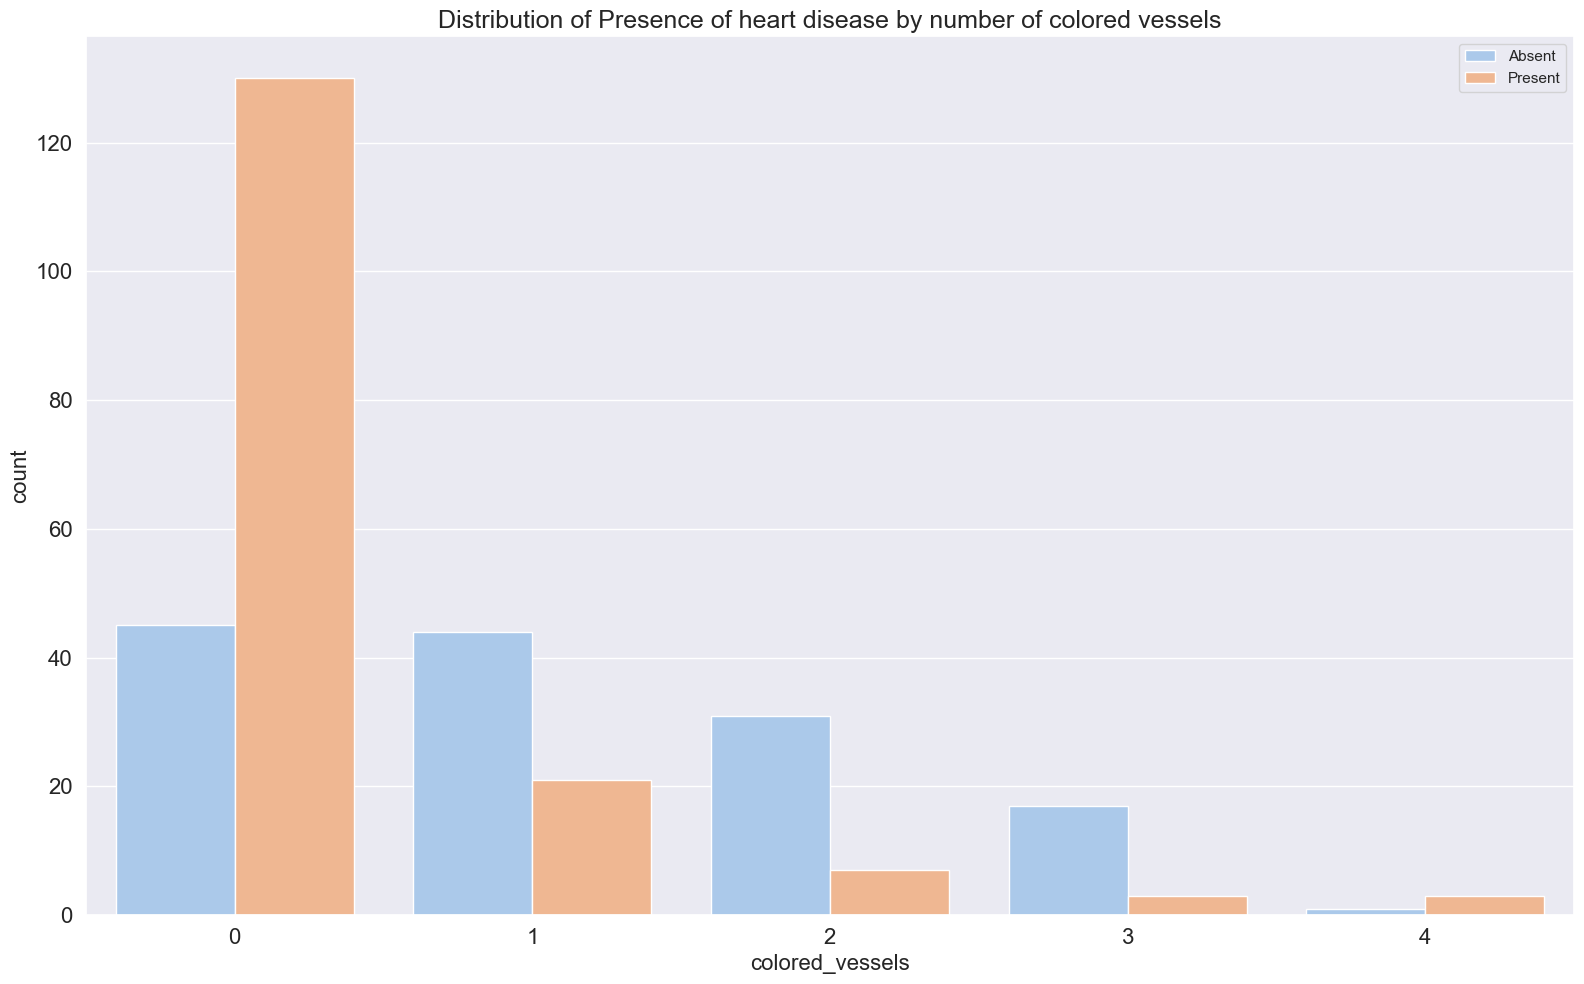

In [ ]:
d = sns.countplot(x = 'colored_vessels', data= df, hue='target', palette='pastel', legend = False)
d.set_title('Distribution of Presence of heart disease by number of colored vessels')
d.set_xticks([0, 1, 2, 3, 4])
d.set_xticklabels(['0', '1', '2', '3', '4'], fontsize = 16)

plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()
plt.show()

Biểu đồ cho thấy đa số bệnh nhân có `colored_vessels = 0` thuộc nhóm mắc bệnh tim. 

Khi số lượng mạch máu được tô màu tăng lên, số bệnh nhân mắc bệnh tim có xu hướng giảm.

=> Kết quả này cho thấy `colored_vessels` có mối quan hệ đáng chú ý với biến mục tiêu và có thể là một đặc trưng quan trọng trong việc phân biệt bệnh nhân có bệnh tim và không có bệnh tim.

In [ ]:
df.slope.value_counts()

slope
2    141
1    140
0     21
Name: count, dtype: int64

Biến `slope` có ba nhóm giá trị, trong đó nhóm `2` và nhóm `1` xuất hiện nhiều nhất, còn nhóm `0` có số lượng ít hơn rõ rệt.

Do `slope` thể hiện độ dốc của đoạn ST sau khi vận động, đây là một biến y khoa có thể phản ánh tình trạng tim mạch của bệnh nhân.

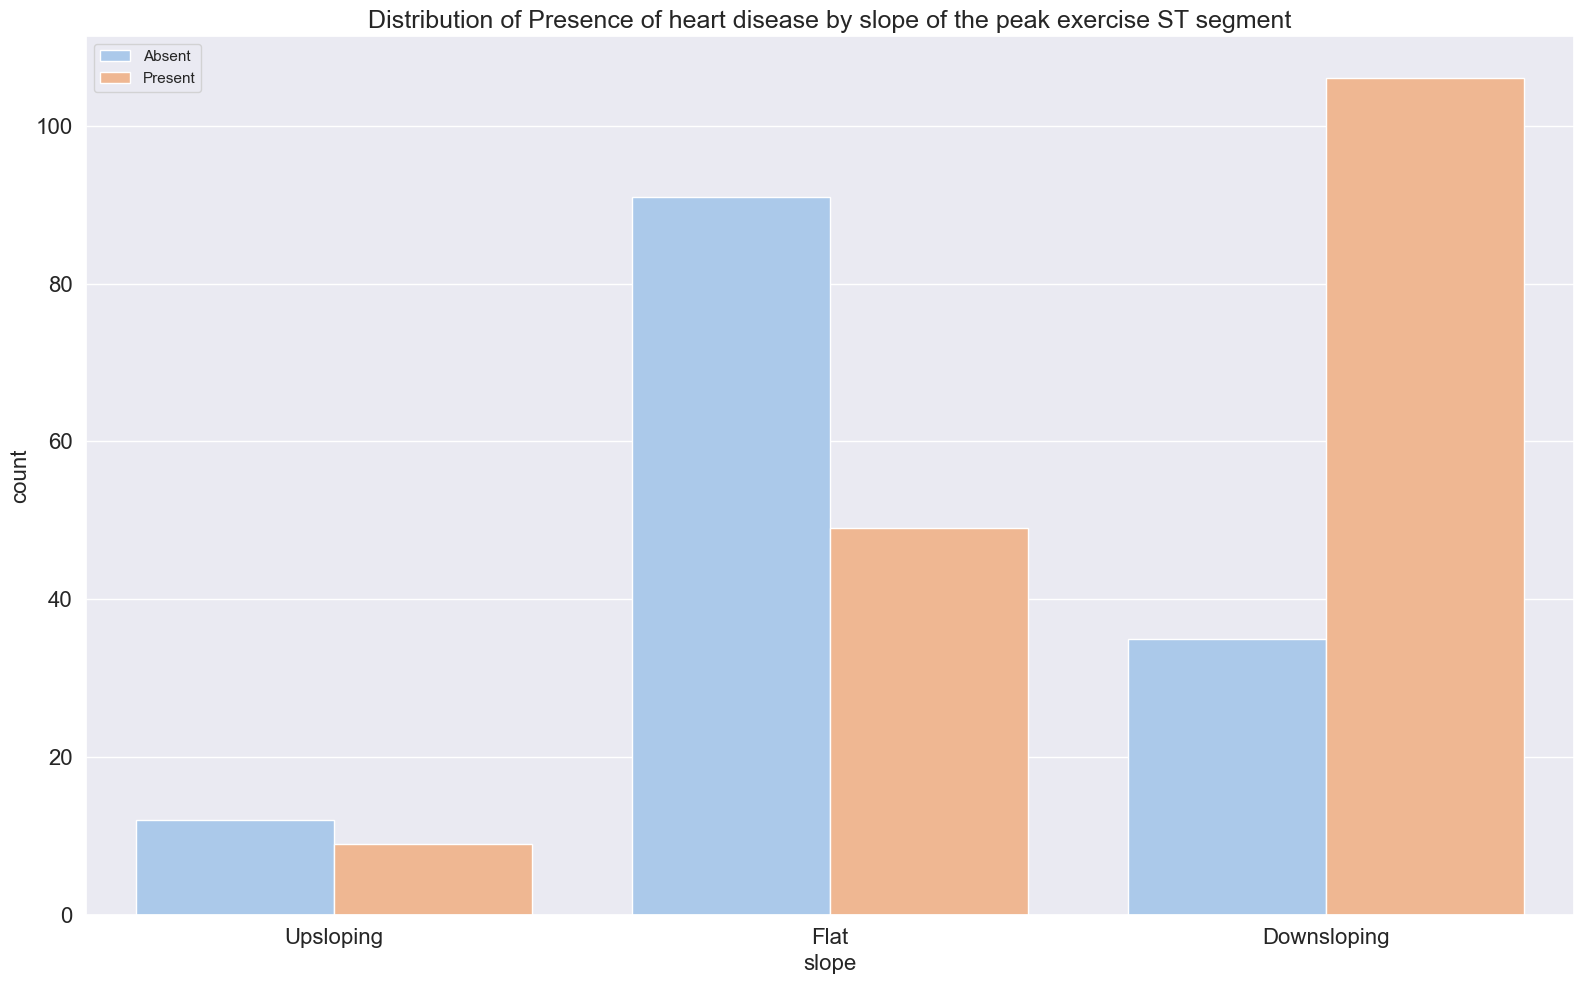

In [ ]:
e = sns.countplot(x = 'slope', data = df, hue = 'target', palette='pastel', legend = False)
e.set_title('Distribution of Presence of heart disease by slope of the peak exercise ST segment')
e.set_xticks([0, 1, 2])
e.set_xticklabels(['Upsloping', 'Flat', 'Downsloping'], fontsize = 16)
plt.legend(labels=['Absent', 'Present'])
plt.tight_layout()  
plt.show()

Biểu đồ cho thấy nhóm `Downsloping` có số bệnh nhân mắc bệnh tim cao nhất. Trong khi đó, nhóm `Flat` có số bệnh nhân không mắc bệnh tim nhiều hơn.

Điều này cho thấy `slope` có mối quan hệ rõ ràng với biến mục tiêu. 

Trong các biến phân loại đã phân tích, `slope` là một trong những đặc trưng thể hiện sự khác biệt khá rõ giữa hai nhóm bệnh nhân.

### 3.4 Relationship between Heart Disease, Age and Maximum Heart Rate
Sau khi phân tích các biến phân loại, ta tiếp tục xem xét các biến liên tục. Trong phần này, scatter plot được sử dụng để quan sát mối quan hệ giữa tuổi, nhịp tim tối đa (`max_hr`) và tình trạng bệnh tim.

Text(0, 0.5, 'Maximum Heart Rate')

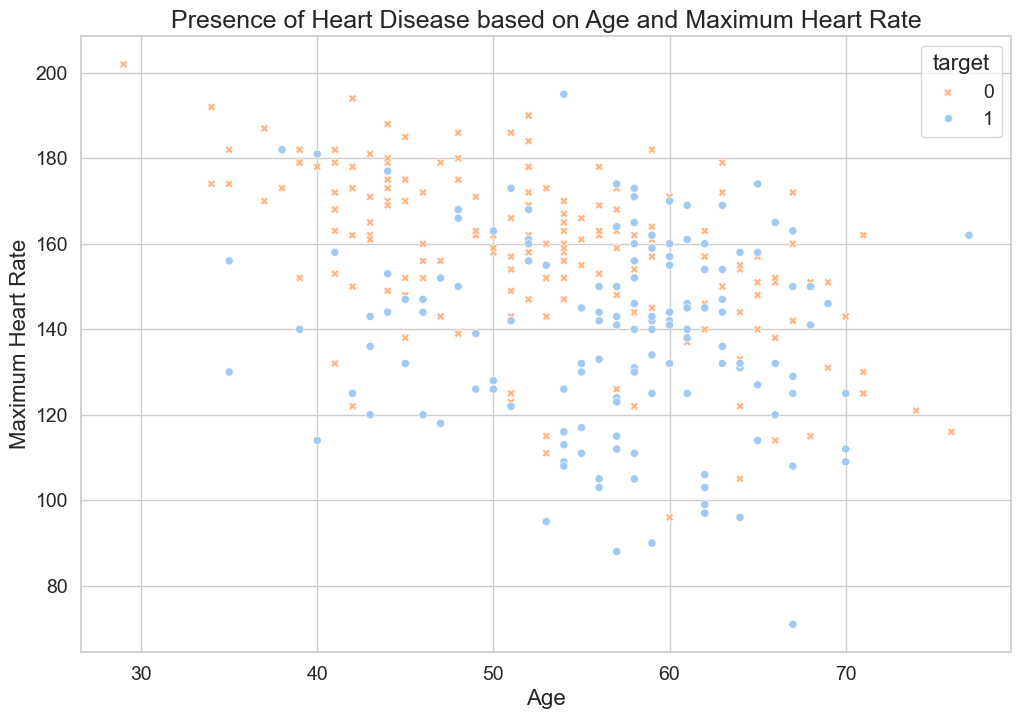

In [ ]:
sns.set(style = 'whitegrid', palette = 'pastel', rc = {"figure.figsize": (12,8), "axes.titlesize" : 18, \
        "axes.labelsize" : 16, "xtick.labelsize" : 16, \
        "ytick.labelsize" : 16 }
)

f = sns.scatterplot(x = 'age', y ='max_hr', hue='target', style='target',data=df, palette= 'pastel', s=35)
f.set_title('Presence of Heart Disease based on Age and '\
            'Maximum Heart Rate')

f.legend(title='target', labels=["0", "1"], loc = 'upper right', fontsize = 14, title_fontsize = 16)

plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')

- Scatter plot cho thấy hai nhóm bệnh nhân có và không có bệnh tim không tách biệt hoàn toàn. 
- Các điểm dữ liệu của hai nhóm vẫn xen lẫn nhau, vì vậy không thể kết luận bằng một ranh giới đơn giản rằng tuổi hoặc nhịp tim tối đa quyết định trực tiếp bệnh tim.

Tuy nhiên, có thể quan sát rằng nhiều bệnh nhân mắc bệnh tim có nhịp tim tối đa tương đối cao. Đáng chú ý, một số bệnh nhân trẻ hơn cũng nằm trong nhóm mắc bệnh tim, cho thấy tuổi không phải là yếu tố duy nhất liên quan đến bệnh tim.

Text(0, 0.5, 'Count')

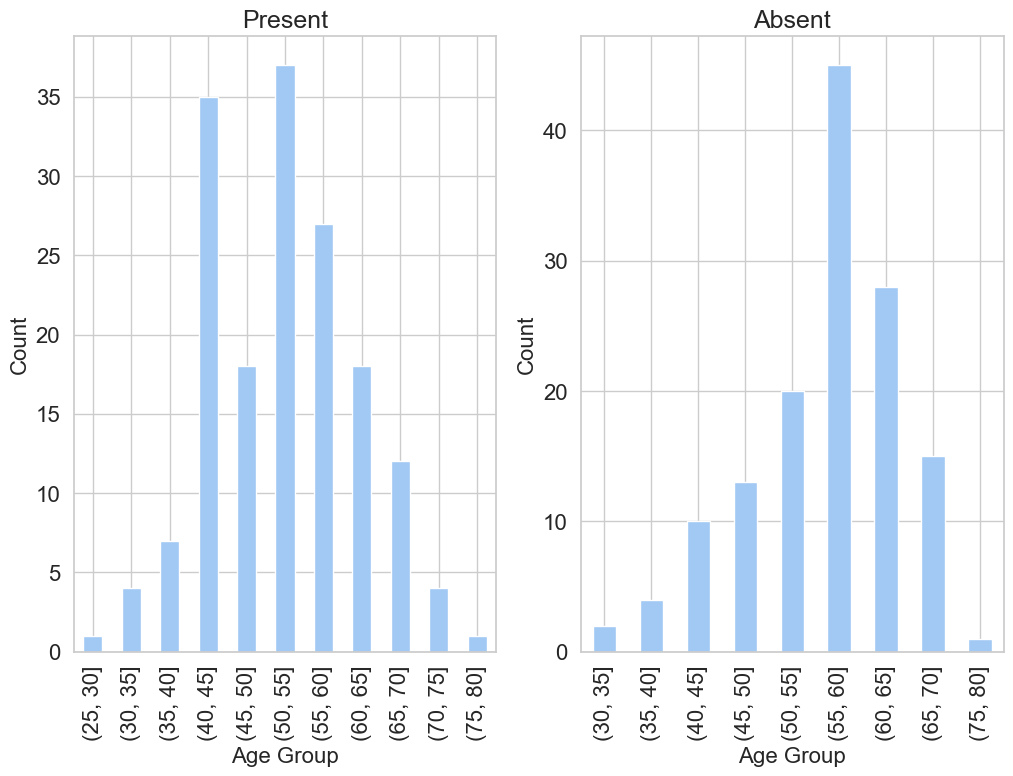

In [ ]:

df['age_category'] = pd.cut(df.age, \
                            bins = list(np.arange(25, 85, 5)))

plt.subplot(121)
df[df.target == 1].groupby('age_category')['age']\
                    .count().plot(kind = 'bar')
                    
plt.title('Present')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.subplot(122)
df[df.target == 0].groupby('age_category')['age']\
.count().plot(kind = 'bar')

plt.title('Absent')
plt.xlabel('Age Group')
plt.ylabel('Count')



Sau khi chia tuổi thành các nhóm 5 năm, biểu đồ cho thấy bệnh tim xuất hiện ở nhiều nhóm tuổi khác nhau, không chỉ tập trung ở nhóm lớn tuổi.

Kết quả này củng cố nhận xét từ scatter plot: trong dataset này, vẫn có khá nhiều bệnh nhân ở nhóm tuổi trẻ hoặc trung niên mắc bệnh tim. Vì vậy, cần phân tích kết hợp tuổi với các đặc trưng khác thay vì chỉ dựa vào tuổi.

### 3.5 Relationship between Heart Disease, Age and Cholesterol
Trong phần này, ta phân tích biến cholesterol (`chol`) để xem liệu cholesterol có thể hiện mối quan hệ rõ ràng với tuổi và tình trạng bệnh tim hay không.

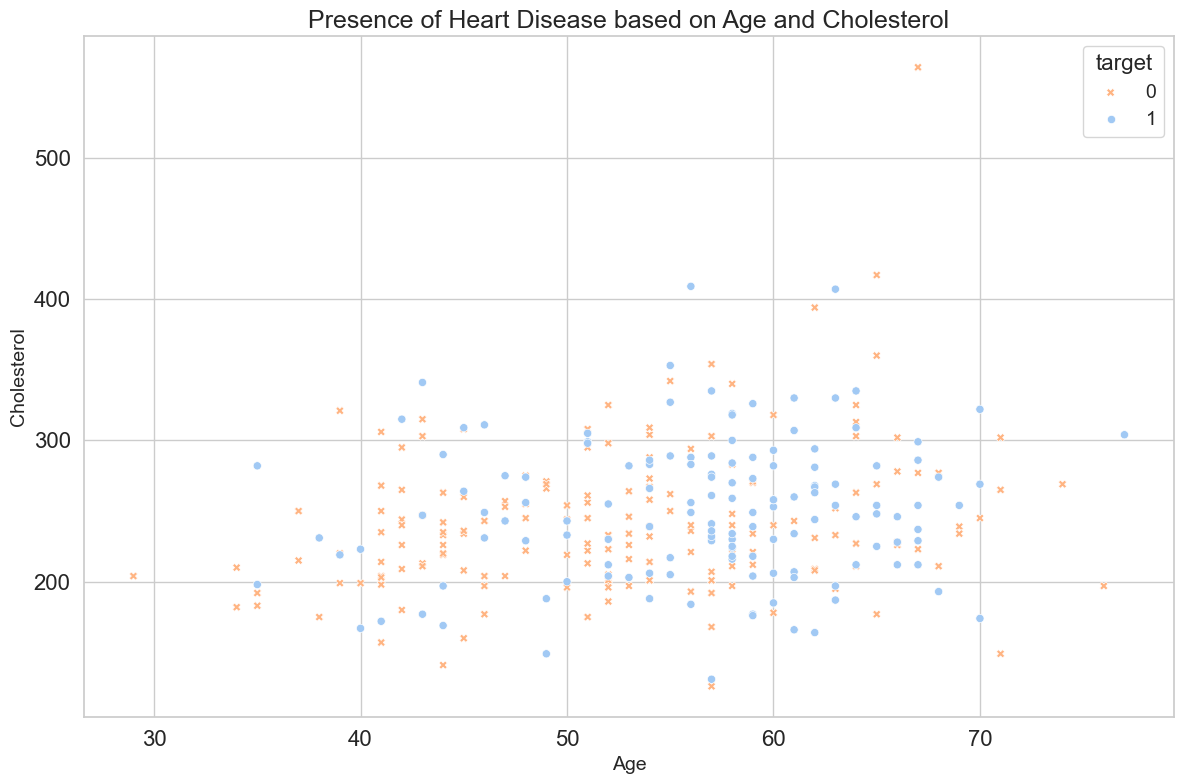

In [ ]:
g = sns.scatterplot(x = 'age', y ='chol', hue ='target', style = 'target', data = df, palette = 'pastel', s = 35)
g.set_title("Presence of Heart Disease based on Age and Cholesterol")

plt.xlabel('Age', fontsize = 14)
plt.ylabel('Cholesterol', fontsize = 14)
g.legend(title = 'target', labels = ["0", "1"], loc = 'upper right', fontsize = 14, title_fontsize = 16)

plt.tight_layout()
plt.show()

- Scatter plot giữa tuổi và cholesterol cho thấy không có sự phân tách rõ ràng giữa nhóm có bệnh tim và không có bệnh tim. 
- Các điểm dữ liệu của hai nhóm phân bố xen lẫn nhau trên nhiều mức cholesterol khác nhau.

Điều này cho thấy cholesterol, khi xét riêng lẻ, không thể hiện mối quan hệ tuyến tính hoặc trực quan mạnh với biến mục tiêu trong dataset này.

Text(0, 0.5, 'Count')

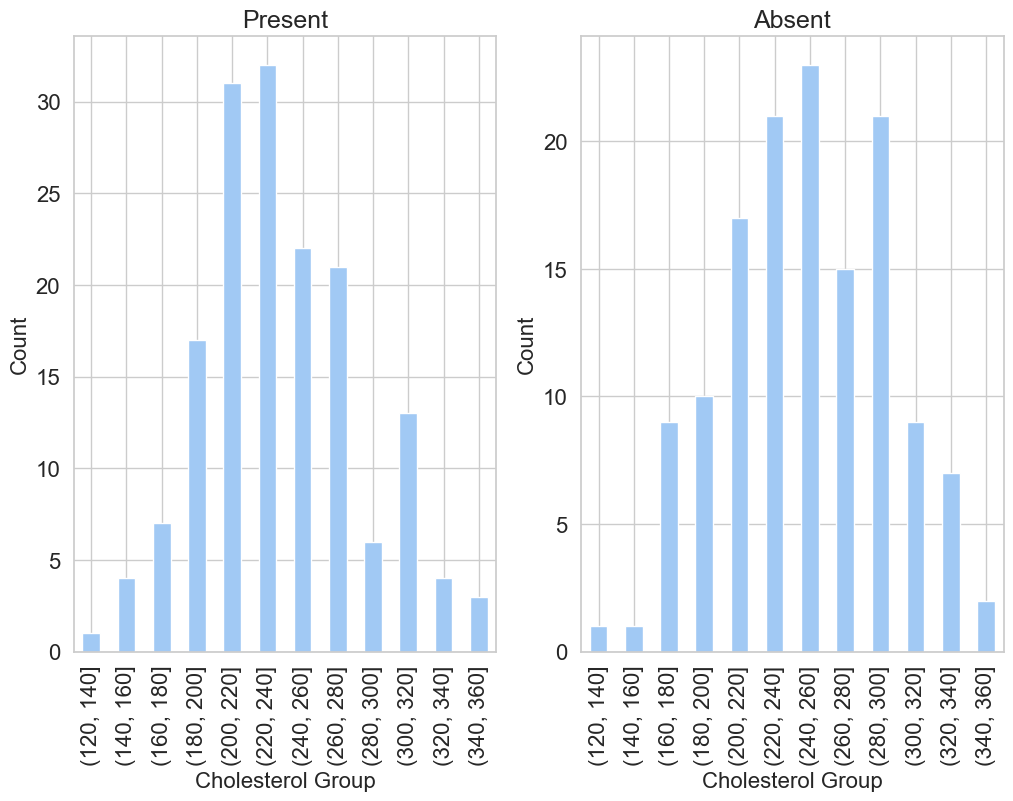

In [ ]:
df['chol_category'] = pd.cut(df.chol, bins = list(np.arange(120, 380, 20)))

#plt.figure(figsize=(10,5))
plt.subplot(121)
df[df.target == 1].groupby('chol_category')['chol']\
                    .count().plot(kind = 'bar')
plt.title('Present')
plt.xlabel('Cholesterol Group')
plt.ylabel('Count')

plt.subplot(122)
df[df.target == 0].groupby('chol_category')['chol']\
.count().plot(kind = 'bar')
plt.title('Absent') 
plt.xlabel('Cholesterol Group')
plt.ylabel('Count')


- Sau khi chia cholesterol thành các nhóm giá trị, biểu đồ vẫn không cho thấy xu hướng rõ ràng giữa cholesterol và bệnh tim. 
- Một số bệnh nhân không mắc bệnh tim vẫn có cholesterol khá cao, trong khi một số bệnh nhân mắc bệnh tim lại nằm ở nhóm cholesterol trung bình.

Vì vậy, có thể kết luận rằng `chol` không phải là đặc trưng có khả năng phân biệt mạnh khi xét riêng lẻ. Đặc trưng này có thể cần được phân tích kết hợp với các biến khác để tạo ra insight rõ hơn.

### 3.6 Correlation Analysis using Heatmap
Heatmap được sử dụng để quan sát hệ số tương quan giữa các đặc trưng trong dataset. Đặc biệt, ta quan tâm đến mối tương quan giữa từng đặc trưng với biến mục tiêu `target`.

Mục đích của bước này là xác định những đặc trưng có ảnh hưởng đáng chú ý đến việc phân biệt bệnh nhân có bệnh tim và không có bệnh tim.

In [ ]:
cols = [
    'age', 'sex', 'chest_pain', 'rest_bp', 'chol',
    'fast_bld_sugar', 'rest_ecg', 'max_hr',
    'ex_angina', 'st_depr', 'slope',
    'colored_vessels', 'thalassemia', 'target'
]

corr = df[cols].corr()

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True,,fmt=".1f", linewidths=0.5, cmap="rocket", square=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

SyntaxError: invalid syntax (3999354294.py, line 11)

Heatmap cho thấy chỉ một số đặc trưng có tương quan đáng chú ý với biến mục tiêu. Các đặc trưng như `slope`, `max_hr` và `chest_pain` thể hiện mối quan hệ rõ hơn với `target` so với nhiều biến còn lại.

Điều này phù hợp với các biểu đồ đã phân tích trước đó: `chest_pain` và `slope` cho thấy sự khác biệt rõ giữa nhóm có bệnh tim và không có bệnh tim, trong khi `max_hr` cũng cho thấy một số xu hướng liên quan đến bệnh tim.

Ngược lại, các biến như `chol` và `fast_bld_sugar` không thể hiện tương quan mạnh với `target`. Điều này không có nghĩa là các biến này hoàn toàn không quan trọng trong thực tế y khoa, mà chỉ cho thấy trong dataset hiện tại, mối quan hệ của chúng với biến mục tiêu không rõ ràng khi xét bằng tương quan tuyến tính.

## 4. Summary

Trong notebook này, ta đã thực hiện phân tích khám phá dữ liệu trên Heart Disease Dataset theo nội dung Chapter 7.

Các kết quả chính gồm:

- Dataset có 303 mẫu và 14 thuộc tính.
- Dữ liệu không có missing values.
- Một số biến như `chol`, `st_depr`, `colored_vessels` và `thalassemia` có xuất hiện outliers, nhưng không bị loại bỏ vì dataset nhỏ và outliers trong dữ liệu y tế có thể mang ý nghĩa thực tế.
- Biến mục tiêu `target` tương đối cân bằng, với số lượng bệnh nhân có và không có bệnh tim không chênh lệch quá lớn.
- Một số đặc trưng phân loại như `chest_pain`, `colored_vessels` và `slope` thể hiện mối quan hệ rõ với bệnh tim.
- Các biến liên tục như `max_hr` có một số xu hướng liên quan đến bệnh tim, trong khi `chol` không cho thấy mối quan hệ rõ ràng khi xét riêng lẻ.
- Heatmap xác nhận rằng chỉ một số đặc trưng có tương quan đáng chú ý với biến mục tiêu, đặc biệt là `slope`, `max_hr` và `chest_pain`.

Nhìn chung, EDA giúp hiểu rõ đặc điểm dữ liệu, phát hiện các điểm bất thường và xác định những đặc trưng có tiềm năng quan trọng nếu tiếp tục xây dựng mô hình dự đoán bệnh tim.